# **Importing Required Modules**

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# **Load Dataset**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/vijayaadithyanvg/car-price-predictionused-cars/car data.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nBasic Stats:")
display(df.describe())

Shape: (301, 9)

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



Data Types:
 Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

Null Values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Basic Stats:


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# **Encoding**

In [3]:
df_model = df.copy()

cat_cols = ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("\nFeature columns:", df_model.drop('Selling_Price', axis=1).columns.tolist())

# ---


Feature columns: ['Car_Name', 'Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


# **Dataset splitting for Training**

In [4]:
X = df_model.drop('Selling_Price', axis=1)
y = df_model['Selling_Price']

# Log-transform target to reduce MAPE and prevent negative predictions
y_log = np.log1p(y)

print("\nTarget range : {:.2f} - {:.2f}".format(y.min(), y.max()))
print("Log range    : {:.2f} - {:.2f}".format(y_log.min(), y_log.max()))


Target range : 0.10 - 35.00
Log range    : 0.10 - 3.58


# **Train & Test Split**

In [5]:
X_train, X_test, ylog_train, ylog_test, y_train, y_test = train_test_split(
    X, y_log, y, test_size=0.2, random_state=42)

print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")


Train size: 240  |  Test size: 61


# **Models**

In [6]:
xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.04,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.75,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    verbosity=0
)

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features=0.75,
    random_state=42,
    n_jobs=-1
)

cat = CatBoostRegressor(
    iterations=400,
    learning_rate=0.04,
    depth=5,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

# **Stacking Ensemble**

In [7]:
estimators = [
    ('xgboost',       xgb),
    ('random_forest', rf),
    ('catboost',      cat),
]

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_train, ylog_train)
print("\nStacking model trained successfully.")


Stacking model trained successfully.


# **Ensemble Metrics**

In [8]:
# Inverse log-transform and clip to ensure no negative prices
ylog_pred = stack_model.predict(X_test)
y_pred    = np.clip(np.expm1(ylog_pred), 0, None)

In [9]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask   = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def med_ape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask   = y_true > 0
    return np.median(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

r2       = r2_score(y_test, y_pred)
mae      = mean_absolute_error(y_test, y_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
mape_val = mape(y_test, y_pred)
medape   = med_ape(y_test, y_pred)

print("\n" + "="*50)
print("          MODEL EVALUATION METRICS")
print("="*50)
print(f"  R2 Score          : {r2:.4f}")
print(f"  MAE   (Rs. Lakhs) : {mae:.4f}")
print(f"  RMSE  (Rs. Lakhs) : {rmse:.4f}")
print(f"  MAPE              : {mape_val:.2f}%  (mean)")
print(f"  MedAPE            : {medape:.2f}%  (median)")
print("="*50)


          MODEL EVALUATION METRICS
  R2 Score          : 0.9713
  MAE   (Rs. Lakhs) : 0.4820
  RMSE  (Rs. Lakhs) : 0.8132
  MAPE              : 13.16%  (mean)
  MedAPE            : 9.42%  (median)


# **Segment-Wise MAPE**

In [10]:
test_df            = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
bins               = [0, 1, 5, 15, 999]
seg_labels         = ['Budget (<1L)', 'Economy (1-5L)', 'Mid (5-15L)', 'Premium (>15L)']
test_df['Segment'] = pd.cut(test_df['Actual'], bins=bins, labels=seg_labels)

print("\nSegment-wise MAPE:")
seg_mape             = test_df.groupby('Segment', observed=True).apply(
    lambda g: mape(g['Actual'], g['Predicted'])
).reset_index()
seg_mape.columns     = ['Segment', 'MAPE (%)']
seg_mape['MAPE (%)'] = seg_mape['MAPE (%)'].round(2)
display(seg_mape)


Segment-wise MAPE:


,Segment,MAPE (%)
0,Budget (<1L),16.00
1,Economy (1-5L),15.21
2,Mid (5-15L),9.30
3,Premium (>15L),11.30


# **K-Fold Cross Validating**

In [11]:
print("\n--- 5-Fold CV R2 Scores (individual base models, log-space) ---")
for name, model in estimators:
    scores = cross_val_score(model, X_train, ylog_train,
                             cv=5, scoring='r2', n_jobs=-1)
    print(f"  {name:20s}: {scores.mean():.4f} +/- {scores.std():.4f}")


--- 5-Fold CV R2 Scores (individual base models, log-space) ---
  xgboost             : 0.9621 +/- 0.0149
  random_forest       : 0.9637 +/- 0.0133
  catboost            : 0.9650 +/- 0.0107


# **Visualizations**

In [12]:
#For Vizualizations Using XGBOOST
xgb.fit(X_train, ylog_train)
feat_imp        = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=False)

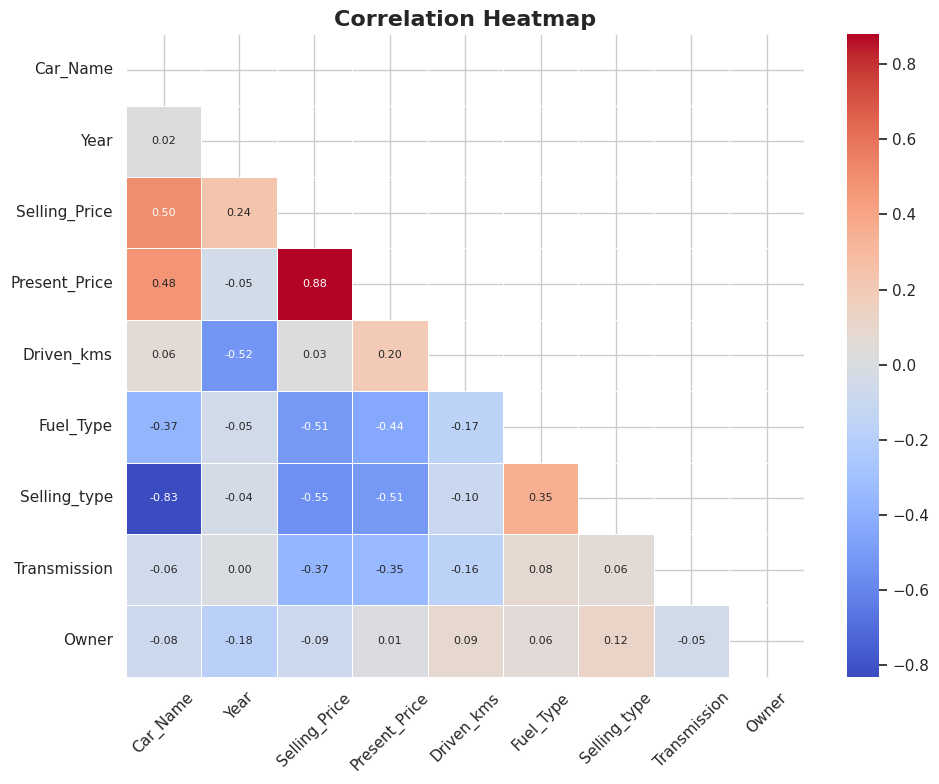

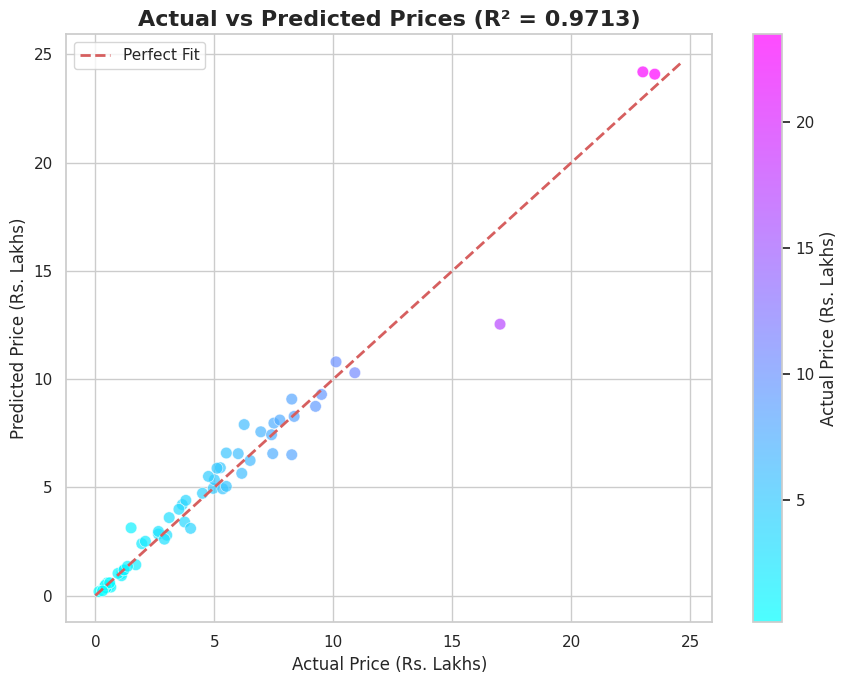

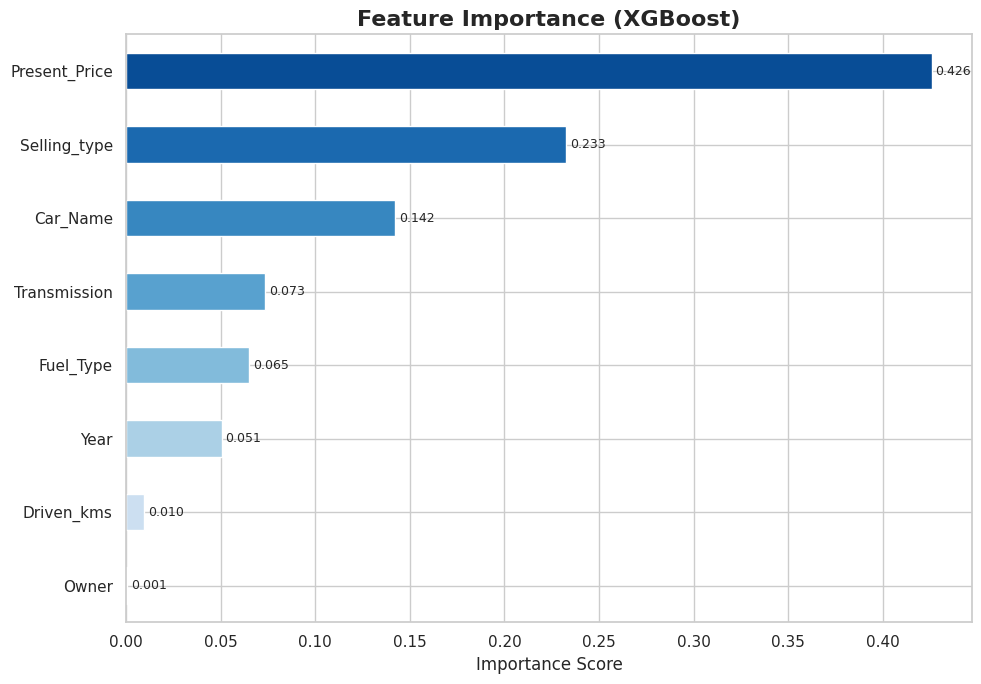

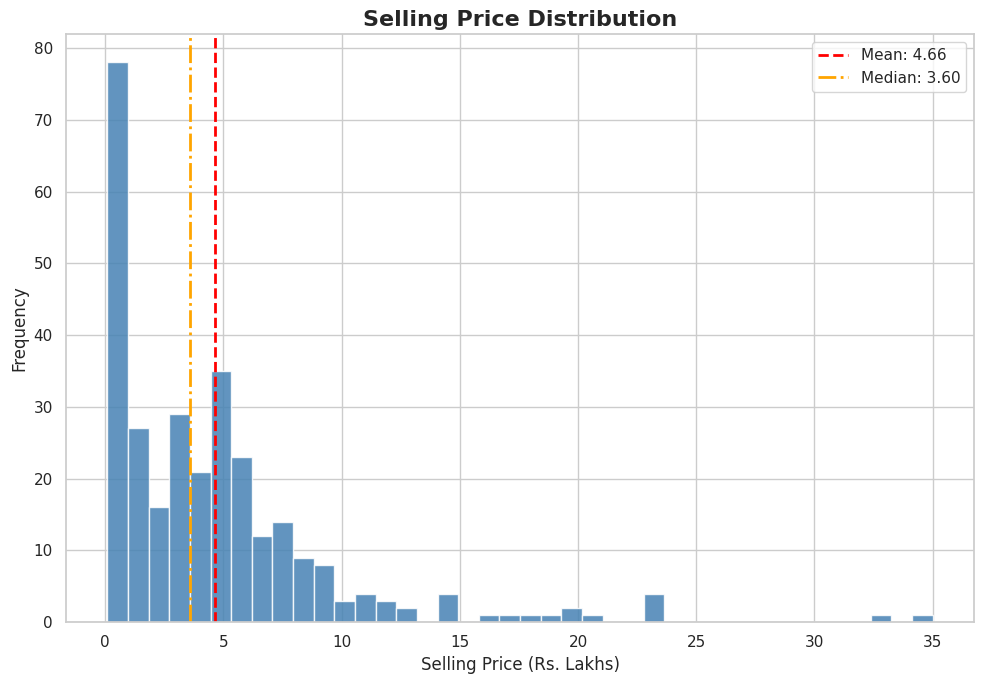

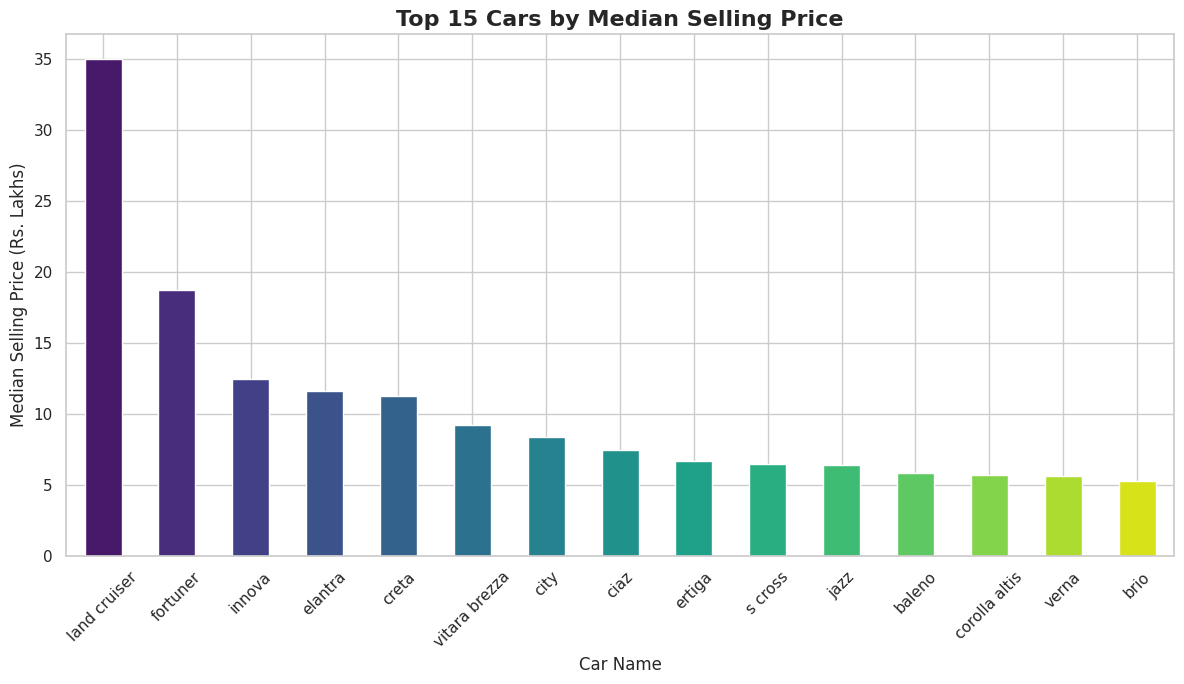

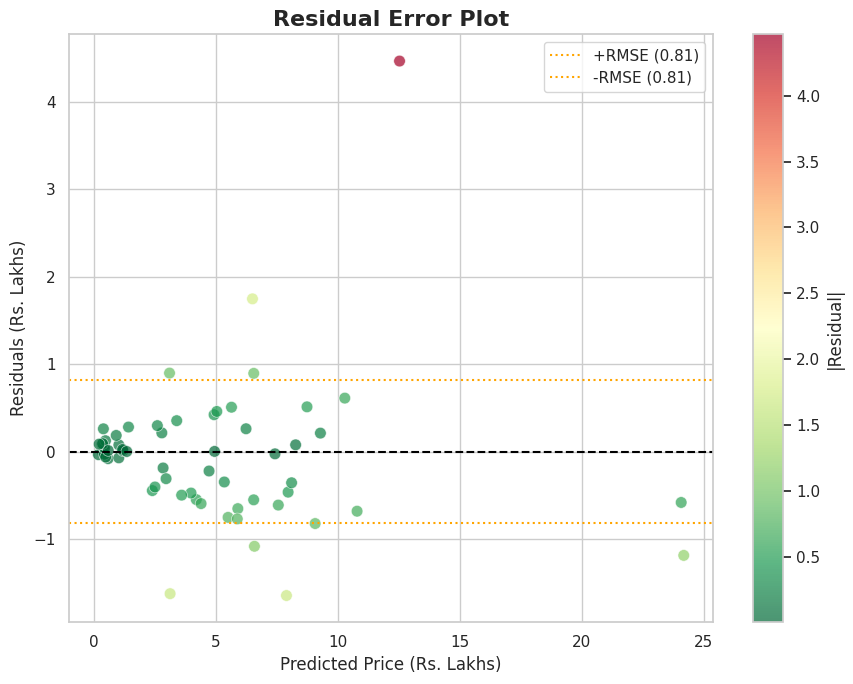


All separate visualizations saved successfully.


In [13]:
sns.set_theme(style='whitegrid', palette='muted')

# (1) CORRELATION HEATMAP
plt.figure(figsize=(10, 8))
corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()


# (2) ACTUAL VS PREDICTED
plt.figure(figsize=(9, 7))
sc = plt.scatter(
    y_test,
    y_pred,
    alpha=0.7,
    c=y_test,
    cmap='cool',
    edgecolors='white',
    linewidths=0.5,
    s=70
)
plt.colorbar(sc, label='Actual Price (Rs. Lakhs)')
lims = [
    max(0, min(y_test.min(), y_pred.min()) - 0.5),
    max(y_test.max(), y_pred.max()) + 0.5
]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit')
plt.xlabel('Actual Price (Rs. Lakhs)', fontsize=12)
plt.ylabel('Predicted Price (Rs. Lakhs)', fontsize=12)
plt.title(
    f'Actual vs Predicted Prices (R² = {r2:.4f})',
    fontsize=16,
    fontweight='bold'
)
plt.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.show()

# (3) FEATURE IMPORTANCE
plt.figure(figsize=(10, 7))
colors = sns.color_palette('Blues_r', len(feat_imp_sorted))
feat_imp_sorted.plot(
    kind='barh',
    color=colors,
    edgecolor='white'
)

plt.gca().invert_yaxis()
plt.xlabel('Importance Score', fontsize=12)
plt.title(
    'Feature Importance (XGBoost)',
    fontsize=16,
    fontweight='bold'
)

for index, value in enumerate(feat_imp_sorted):
    plt.text(
        value + 0.002,
        index,
        f'{value:.3f}',
        va='center',
        fontsize=9
    )
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()


# (4) PRICE DISTRIBUTION
plt.figure(figsize=(10, 7))
plt.hist(
    df['Selling_Price'],
    bins=40,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)
plt.axvline(
    df['Selling_Price'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {df["Selling_Price"].mean():.2f}'
)
plt.axvline(
    df['Selling_Price'].median(),
    color='orange',
    linestyle='-.',
    linewidth=2,
    label=f'Median: {df["Selling_Price"].median():.2f}'
)

plt.xlabel('Selling Price (Rs. Lakhs)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(
    'Selling Price Distribution',
    fontsize=16,
    fontweight='bold'
)

plt.legend()
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=300)
plt.show()


# (5) TOP 15 CARS BY MEDIAN SELLING PRICE

plt.figure(figsize=(12, 7))

car_med = (
    df.groupby('Car_Name')['Selling_Price']
      .median()
      .sort_values(ascending=False)
      .head(15)
)

colors_b = sns.color_palette('viridis', len(car_med))

car_med.plot(
    kind='bar',
    color=colors_b,
    edgecolor='white'
)

plt.xlabel('Car Name', fontsize=12)
plt.ylabel('Median Selling Price (Rs. Lakhs)', fontsize=12)

plt.title(
    'Top 15 Cars by Median Selling Price',
    fontsize=16,
    fontweight='bold'
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('top15_car_prices.png', dpi=300)
plt.show()

# (6) RESIDUAL ERROR PLOT
plt.figure(figsize=(9, 7))
residuals = y_test.values - y_pred
sc2 = plt.scatter(
    y_pred,
    residuals,
    alpha=0.7,
    c=np.abs(residuals),
    cmap='RdYlGn_r',
    edgecolors='white',
    linewidths=0.5,
    s=70
)

plt.colorbar(sc2, label='|Residual|')
plt.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.5
)
plt.axhline(
    rmse,
    color='orange',
    linestyle=':',
    linewidth=1.5,
    label=f'+RMSE ({rmse:.2f})'
)
plt.axhline(
    -rmse,
    color='orange',
    linestyle=':',
    linewidth=1.5,
    label=f'-RMSE ({rmse:.2f})'
)
plt.xlabel('Predicted Price (Rs. Lakhs)', fontsize=12)
plt.ylabel('Residuals (Rs. Lakhs)', fontsize=12)
plt.title(
    'Residual Error Plot',
    fontsize=16,
    fontweight='bold'
)

plt.legend()
plt.tight_layout()
plt.savefig('residual_error_plot.png', dpi=300)
plt.show()


print("\nAll separate visualizations saved successfully.")

# **Sample Predictions**

In [14]:
results_df = pd.DataFrame({
    'Metric': ['R2 Score', 'MAE (Rs. Lakhs)', 'RMSE (Rs. Lakhs)', 'MAPE (%)', 'MedAPE (%)'],
    'Value':  [f'{r2:.4f}', f'{mae:.4f}', f'{rmse:.4f}', f'{mape_val:.2f}', f'{medape:.2f}']
})
print("\nFinal Metrics Summary:")
display(results_df)


Final Metrics Summary:


,Metric,Value
0,R2 Score,0.9713
1,MAE (Rs. Lakhs),0.4820
2,RMSE (Rs. Lakhs),0.8132
3,MAPE (%),13.16
4,MedAPE (%),9.42


In [15]:
sample = pd.DataFrame({
    'Actual (Rs.L)':    np.round(y_test.values[:10], 2),
    'Predicted (Rs.L)': np.round(y_pred[:10], 2),
    'Error (Rs.L)':     np.round(np.abs(y_test.values[:10] - y_pred[:10]), 2),
    'APE (%)':          np.round(
        np.abs(y_test.values[:10] - y_pred[:10]) /
        np.where(y_test.values[:10] > 0, y_test.values[:10], np.nan) * 100, 1)
})
print("\nSample Predictions (first 10 test rows):")
display(sample)


Sample Predictions (first 10 test rows):


,Actual (Rs.L),Predicted (Rs.L),Error (Rs.L),APE (%)
0,0.35,0.36,0.01,2.1
1,10.11,10.79,0.68,6.7
2,4.95,4.95,0.00,0.0
3,0.15,0.19,0.04,23.5
4,6.95,7.56,0.61,8.8
5,7.45,6.56,0.89,12.0
6,1.10,1.02,0.08,6.9
7,0.50,0.58,0.08,16.2
8,0.45,0.40,0.05,11.8
9,6.00,6.55,0.55,9.2


# **Saving Trained models**

In [16]:
joblib.dump(xgb,         'model_xgboost.pkl')
joblib.dump(rf,          'model_random_forest.pkl')
joblib.dump(cat,         'model_catboost.pkl')
joblib.dump(stack_model, 'model_stacking_ensemble.pkl')
print("\nAll models saved.")


All models saved.
